Charlie Frank

## Homework 5

### Complex capacity expansion planning

In this homework assignment, we will explore the workings of a complex electricity system capacity expansion planning model that includes chronologically sequential operational decisions with time coupling constraints and transport flow constraints to represent power transmission limits between multiple geospatial regions.

The 'core' model and data we will use are provided in [Notebooks/extra_labs/Lab2/Lab2.jl](https://github.com/Power-Systems-Optimization-Course/power-systems-optimization/blob/master/Notebooks/extra_labs/Lab2/Lab2.jl), [Notebooks/extra_labs/Lab2/Lab2_code.jl](https://github.com/Power-Systems-Optimization-Course/power-systems-optimization/blob/master/Notebooks/extra_labs/Lab2/Lab2_code.jl) and the [complex_expansion_data](https://github.com/Power-Systems-Optimization-Course/power-systems-optimization/tree/master/Notebooks/complex_expansion_data) folder. This core model includes economic dispatch decisions with ramp constraints for thermal generators and storage constraints (**but no thermal unit commitment constraints/decisions**). It uses a simplified capacitated transport flow constraint to represent inter-regional electricity transmission between three regions (rather than DC OPF constraints), with data representing the Electricity Reliability Corporation of Texas (ERCOT) region.

### Part 1: Time domain reduction methods

To reduce dimensionality and keep runtimes manageable for a tutorial assignment running on a desktop or laptop computer, we provide a set of *N* representative time periods of *Y* consecutive hourly periods (here either 24 hour days or 168 hour weeks) selected via a clustering method adapted from Mallapragada et al. (2018), "[Impact of model resolution on scenario outcomes for electricity sector system expansion](https://doi.org/10.1016/j.energy.2018.08.015)" Energy 163). 

This method creates clusters of representative periods by trying to minimize variation between time series for wind, solar, and demand in each of the within-cluster periods (days or weeks). It also always includes the period containing the peak demand hour, if this period was not already selected as a cluster centroid. 

To represent a full year of hourly operations, hours within each time period are weighted by a multiplier equal to the total number of periods (days or weeks) within the cluster represented by each representative period. In the objective function of the model, variable costs incurred in each hour are thus multiplied by this hourly weight to represent the cost of a full year of operation, as shown in the following two expressions, which make up the variable cost related part of the model objective function: 

In [22]:
# @expression(Expansion_Model, eVariableCosts,
#      # Variable costs for generation, weighted by hourly sample weight
#     sum(sample_weight[t]*generators.Var_Cost[g]*vGEN[t,g] for t in T, g in G)
# )
# @expression(Expansion_Model, eNSECosts,
#      # Non-served energy costs
#     sum(sample_weight[t]*nse.NSE_Cost[s]*vNSE[t,s,z] for t in T, s in S, z in Z)
# )

For example, if a representative day represents a cluster with 8 total days, variable costs incurred in each hour in that representative period are multiplied by a `sample_weight` of 8, to represent repeated similar operational patterns in the clustered days. 

While time sampling methods like this can significantly reduce computational time, they also introduce abstraction errors that can bias model results. In this part of the assignment, we will explore these tradeoffs.

In [23]:
using JuMP
using HiGHS
using Plots
using DataFrames, CSV
using Gurobi
using Printf

#### Question 1(a)

Copy the package commands and methods from `Lab2_code.jl` (except for `solve_cap_expansion_uc` which is not needed here).

In addition, copy the commands from `Lab2.jl` (load inputs, solve model, write results, etc.).

The model provided uses 10 representative days of data, and also records the solution time to a file in the output directory. 

However in the data folder (`Notebooks/complex_expansion_data`) there is also data for 4 weeks, 8 weeks, 16 weeks, and 52 weeks of representative periods.

**Run the model for four of these temporal resolutions.** Each time you run the model, (a) record the solution time, and (b) save your outputs to a different folder named `/10_days_Your_Name`, `/4_weeks_Your_Name`, `8_weeks_Your_Name`, and `16_weeks_Your_Name`.

Create and save a scatter plot that shows the solution time in seconds (y axis) and the number of hours included in the model for the 10 days (240 hours), 4 weeks (672 hours), 8 weeks (1344 hours), and 16 weeks (2688) iterations. What do you notice about the increase in solution time? How does the computational performance of the model appear to scale as the number of time steps in the model (hours) increases?

In [24]:
function load_input_generator(inputs_path)

    # Generators (and storage) data:
    generators = DataFrame(CSV.File(joinpath(inputs_path, "Generators_data.csv")))
    # Read fuels data
    fuels = DataFrame(CSV.File(joinpath(inputs_path, "Fuels_data.csv")))

    # Select the columns needed for this model
    generators = select(generators, :R_ID, :Resource, :zone, :THERM, :DISP, :NDISP, :STOR, :HYDRO, :RPS, :CES,
        :Commit, :Existing_Cap_MW, :Existing_Cap_MWh, :Cap_size, :New_Build, :Max_Cap_MW,
        :Inv_cost_per_MWyr, :Fixed_OM_cost_per_MWyr, :Inv_cost_per_MWhyr, :Fixed_OM_cost_per_MWhyr,
        :Var_OM_cost_per_MWh, :Start_cost_per_MW, :Start_fuel_MMBTU_per_MW, :Heat_rate_MMBTU_per_MWh, :Fuel,
        :Min_power, :Ramp_Up_percentage, :Ramp_Dn_percentage, :Up_time, :Down_time,
        :Eff_up, :Eff_down)

    # Set of all generators
    G = generators.R_ID

    # Calculate total variable costs, start-up costs, CO2 rates
    generators.Var_Cost = zeros(Float64, size(G, 1))
    generators.CO2_Rate = zeros(Float64, size(G, 1))
    generators.Start_Cost = zeros(Float64, size(G, 1))
    generators.CO2_Per_Start = zeros(Float64, size(G, 1))

    for g in G
        # Variable cost ($/MWh) = variable O&M ($/MWh) + fuel cost ($/MMBtu) * heat rate (MMBtu/MWh)
        generators.Var_Cost[g] = generators.Var_OM_cost_per_MWh[g] +
                                  fuels[fuels.Fuel.==generators.Fuel[g], :Cost_per_MMBtu][1] *
                                  generators.Heat_rate_MMBTU_per_MWh[g]
        # CO2 emissions rate (tCO2/MWh)
        generators.CO2_Rate[g] = fuels[fuels.Fuel.==generators.Fuel[g], :CO2_content_tons_per_MMBtu][1] *
                                   generators.Heat_rate_MMBTU_per_MWh[g]
        # Start-up cost ($/start/MW)
        generators.Start_Cost[g] = generators.Start_cost_per_MW[g] +
                                     fuels[fuels.Fuel.==generators.Fuel[g], :Cost_per_MMBtu][1] *
                                     generators.Start_fuel_MMBTU_per_MW[g]
        # Start-up CO2 emissions (tCO2/start/MW)
        generators.CO2_Per_Start[g] = fuels[fuels.Fuel.==generators.Fuel[g], :CO2_content_tons_per_MMBtu][1] *
                                        generators.Start_fuel_MMBTU_per_MW[g]
    end

    # Drop hydropower and biomass plants (small share of ERCOT capacity)
    G = intersect(generators.R_ID[.!(generators.HYDRO .== 1)], G)
    G = intersect(generators.R_ID[.!(generators.NDISP .== 1)], G)

    # Override storage energy investment cost to $400/MWhyr
    generators[generators.STOR.>=1, :Inv_cost_per_MWhyr] .= 400

    return (generators, G)
end

load_input_generator (generic function with 1 method)

In [25]:
function load_input_demand(inputs_path)
    # Read demand input data and record parameters
    demand_inputs = DataFrame(CSV.File(joinpath(inputs_path, "Load_data.csv")))

    # Value of lost load (cost of involuntary non-served energy)
    VOLL = demand_inputs.Voll[1]
    # Set of price responsive demand (non-served energy) segments
    S = convert(Array{Int64}, collect(skipmissing(demand_inputs.Demand_segment)))

    # NSE data frame: cost and max curtailment fraction per segment
    nse = DataFrame(
        Segment = S,
        NSE_Cost = VOLL .* collect(skipmissing(demand_inputs.Cost_of_demand_curtailment_perMW)),
        NSE_Max = collect(skipmissing(demand_inputs.Max_demand_curtailment)),
    )

    # Sequential hours per sub-period
    hours_per_period = convert(Int64, demand_inputs.Hours_per_period[1])
    # Sample sub-periods
    P = convert(Array{Int64}, 1:demand_inputs.Subperiods[1])
    # Sub-period cluster weights
    W = convert(Array{Int64}, collect(skipmissing(demand_inputs.Sub_Weights)))
    # All time steps
    T = convert(Array{Int64}, demand_inputs.Time_index)

    # Sample weights: hours-per-year represented by each modelled hour
    sample_weight = zeros(Float64, size(T, 1))
    t = 1
    for p in P
        for h in 1:hours_per_period
            sample_weight[t] = W[p] / hours_per_period
            t = t + 1
        end
    end

    # Three zones (Texas Panhandle, Eastern ERCOT, Western ERCOT)
    Z = convert(Array{Int64}, 1:3)

    # Load time series by zone
    demand = select(demand_inputs, :Load_MW_z1, :Load_MW_z2, :Load_MW_z3)

    return (demand, nse, sample_weight, hours_per_period, P, S, W, T, Z)
end


function load_input_variability(inputs_path)

    variability = DataFrame(CSV.File(joinpath(inputs_path, "Generators_variability.csv")))
    # Drop the row-index column
    variability = variability[:, 2:ncol(variability)]

    return variability
end


function load_input_network(inputs_path)

    network = DataFrame(CSV.File(joinpath(inputs_path, "Network.csv")))

    zones = collect(skipmissing(network.Network_zones))

    lines = select(network[1:2, :],
        :Network_lines, :z1, :z2, :z3,
        :Line_Max_Flow_MW, :Line_Min_Flow_MW, :Line_Loss_Percentage,
        :Line_Max_Reinforcement_MW, :Line_Reinforcement_Cost_per_MW_yr)

    # Fixed O&M for existing transmission = 1/20 of reinforcement cost
    lines.Line_Fixed_Cost_per_MW_yr = lines.Line_Reinforcement_Cost_per_MW_yr ./ 20

    L = convert(Array{Int64}, lines.Network_lines)

    return (lines, L)
end

load_input_network (generic function with 1 method)

In [26]:
function solve_cap_expansion(generators, G,
    demand, S, T, Z,
    nse,
    sample_weight, hours_per_period,
    lines, L,
    variability, solver)

    # SUBSETS 
    UC = intersect(generators.R_ID[generators.Commit.==1], G)
    ED = intersect(generators.R_ID[.!(generators.Commit .== 1)], G)
    STOR = intersect(generators.R_ID[generators.STOR.>=1], G)
    VRE = intersect(generators.R_ID[generators.DISP.==1], G)
    NEW = intersect(generators.R_ID[generators.New_Build.==1], G)
    OLD = intersect(generators.R_ID[.!(generators.New_Build .== 1)], G)
    RPS = intersect(generators.R_ID[generators.RPS.==1], G)

    Expansion_Model = Model(solver)

    # DECISION VARIABLES

   # Capacity variables
    @variables(Expansion_Model, begin
        vCAP[g in G] >= 0   # total power capacity (MW)
        vRET_CAP[g in OLD] >= 0 # retired power capacity (MW)
        vNEW_CAP[g in NEW] >= 0   # new build power capacity (MW)

        vE_CAP[g in STOR] >= 0   # storage energy capacity (MWh)
        vRET_E_CAP[g in intersect(STOR, OLD)]  >= 0   # retired storage energy capacity (MWh)
        vNEW_E_CAP[g in intersect(STOR, NEW)]  >= 0   # new storage energy capacity (MWh)

        vT_CAP[l in L] >= 0   # transmission capacity (MW)
        vRET_T_CAP[l in L] >= 0   # retired transmission capacity (MW)
        vNEW_T_CAP[l in L] >= 0   # new transmission capacity (MW)
    end)

    # Upper bounds on renewable capacity (cluster limits)
    for g in NEW[generators[NEW, :Max_Cap_MW].>0]
        set_upper_bound(vNEW_CAP[g], generators.Max_Cap_MW[g])
    end

    # Upper bounds on transmission reinforcement
    for l in L
        set_upper_bound(vNEW_T_CAP[l], lines.Line_Max_Reinforcement_MW[l])
    end

    # Operational variables
    @variables(Expansion_Model, begin
        vGEN[T, G] >= 0   # power generation (MW)
        vCHARGE[T, STOR] >= 0  # storage charging (MW)
        vSOC[T, STOR] >= 0   # storage state of charge (MWh)
        vNSE[T, S, Z] >= 0 # non-served energy / demand curtailment (MW)
        vFLOW[T, L]  # transmission line flow (MW)
    end)

    # CONSTRAINTS

    # (1) Supply-demand balance for every hour and zone
    @constraint(Expansion_Model, cDemandBalance[t in T, z in Z],
        sum(vGEN[t, g] for g in intersect(generators[generators.zone.==z, :R_ID], G)) +
        sum(vNSE[t, s, z] for s in S) -
        sum(vCHARGE[t, g] for g in intersect(generators[generators.zone.==z, :R_ID], STOR)) -
        demand[t, z] -
        sum(lines[l, Symbol(string("z", z))] * vFLOW[t, l] for l in L) == 0
    )

    # (2–6) Capacitated operating constraints
    @constraints(Expansion_Model, begin
        # (2) Max power output
        cMaxPower[t in T, g in G],
            vGEN[t, g] <= variability[t, g] * vCAP[g]
        # (3) Max storage charge rate
        cMaxCharge[t in T, g in STOR],
            vCHARGE[t, g] <= vCAP[g]
        # (4) Max state of charge
        cMaxSOC[t in T, g in STOR],
            vSOC[t, g] <= vE_CAP[g]
        # (5) Max non-served energy per segment and zone
        cMaxNSE[t in T, s in S, z in Z],
            vNSE[t, s, z] <= nse.NSE_Max[s] * demand[t, z]
        # (6a) Max transmission flow
        cMaxFlow[t in T, l in L],
            vFLOW[t, l] <= vT_CAP[l]
        # (6b) Min transmission flow (bidirectional)
        cMinFlow[t in T, l in L],
            vFLOW[t, l] >= -vT_CAP[l]
    end)

    # (7–9) Capacity accounting constraints
    @constraints(Expansion_Model, begin
        # (7a) Existing generator capacity
        cCapOld[g in OLD],
            vCAP[g] == generators.Existing_Cap_MW[g] - vRET_CAP[g]
        # (7b) New generator capacity
        cCapNew[g in NEW],
            vCAP[g] == vNEW_CAP[g]
        # (8a) Existing storage energy capacity
        cCapEnergyOld[g in intersect(STOR, OLD)],
            vE_CAP[g] == generators.Existing_Cap_MWh[g] - vRET_E_CAP[g]
        # (8b) New storage energy capacity
        cCapEnergyNew[g in intersect(STOR, NEW)],
            vE_CAP[g] == vNEW_E_CAP[g]
        # (9) Transmission capacity
        cTransCap[l in L],
            vT_CAP[l] == lines.Line_Max_Flow_MW[l] - vRET_T_CAP[l] + vNEW_T_CAP[l]
    end)

    # STARTS: first hour of each sample period 
    STARTS = convert(Array{Int64},
                    1:hours_per_period:floor(maximum(T) / hours_per_period) * hours_per_period)
    INTERIORS = setdiff(T, STARTS)

    # (10–12) Time-coupling constraints
    @constraints(Expansion_Model, begin
        # (10a) Ramp up, interior hours
        cRampUp[t in INTERIORS, g in G],
            vGEN[t, g] - vGEN[t-1, g] <= generators.Ramp_Up_percentage[g] * vCAP[g]
        # (10b) Ramp up, period wrap
        cRampUpWrap[t in STARTS, g in G],
            vGEN[t, g] - vGEN[t+hours_per_period-1, g] <= generators.Ramp_Up_percentage[g] * vCAP[g]
        # (11a) Ramp down, interior hours
        cRampDown[t in INTERIORS, g in G],
            vGEN[t-1, g] - vGEN[t, g] <= generators.Ramp_Dn_percentage[g] * vCAP[g]
        # (11b) Ramp down, period wrap
        cRampDownWrap[t in STARTS, g in G],
            vGEN[t+hours_per_period-1, g] - vGEN[t, g] <= generators.Ramp_Dn_percentage[g] * vCAP[g]
        # (12a) Storage state of charge, interior hours
        cSOC[t in INTERIORS, g in STOR],
            vSOC[t, g] == vSOC[t-1, g] +
                          generators.Eff_up[g] * vCHARGE[t, g] -
                          vGEN[t, g] / generators.Eff_down[g]
        # (12b) Storage state of charge, period wrap
        cSOCWrap[t in STARTS, g in STOR],
            vSOC[t, g] == vSOC[t+hours_per_period-1, g] +
                          generators.Eff_up[g] * vCHARGE[t, g] -
                          vGEN[t, g] / generators.Eff_down[g]
    end)

    # OBJECTIVE FUNCTION 

    @expression(Expansion_Model, eFixedCostsGeneration,
        # Fixed O&M for all capacity
        sum(generators.Fixed_OM_cost_per_MWyr[g] * vCAP[g] for g in G) +
        # Investment cost for new capacity
        sum(generators.Inv_cost_per_MWyr[g] * vNEW_CAP[g] for g in NEW)
    )

    @expression(Expansion_Model, eFixedCostsStorage,
        # Fixed O&M for storage energy capacity
        sum(generators.Fixed_OM_cost_per_MWhyr[g] * vE_CAP[g] for g in STOR) +
        # Investment cost for new storage energy capacity
        sum(generators.Inv_cost_per_MWhyr[g] * vNEW_CAP[g] for g in intersect(STOR, NEW))
    )

    @expression(Expansion_Model, eFixedCostsTransmission,
        # Fixed O&M + investment cost for transmission
        sum(lines.Line_Fixed_Cost_per_MW_yr[l] * vT_CAP[l] +
            lines.Line_Reinforcement_Cost_per_MW_yr[l] * vNEW_T_CAP[l] for l in L)
    )

    @expression(Expansion_Model, eVariableCosts,
        # Variable generation costs, weighted by sample period weights
        sum(sample_weight[t] * generators.Var_Cost[g] * vGEN[t, g] for t in T, g in G)
    )

    @expression(Expansion_Model, eNSECosts,
        # Non served energy costs
        sum(sample_weight[t] * nse.NSE_Cost[s] * vNSE[t, s, z] for t in T, s in S, z in Z)
    )

    @expression(Expansion_Model, eTotalCosts,
        eFixedCostsGeneration + eFixedCostsStorage + eFixedCostsTransmission +
        eVariableCosts + eNSECosts
    )

    @objective(Expansion_Model, Min, eTotalCosts)

    # SOLVE
    elapsed_time = @elapsed optimize!(Expansion_Model)

    # EXTRACT RESULTS

    # Generation capacity and energy results
    generation = zeros(size(G, 1))
    for i in 1:size(G, 1)
        generation[i] = sum(sample_weight .* value.(vGEN)[:, G[i]].data)
    end
    total_demand = sum(sum.(eachcol(sample_weight .* demand)))
    peak_demand = maximum(sum(eachcol(demand)))
    MWh_share = generation ./ total_demand .* 100
    cap_share = value.(vCAP).data ./ peak_demand .* 100

    generator_results = DataFrame(
        ID = G,
        Resource = generators.Resource[G],
        Zone = generators.zone[G],
        Total_MW = value.(vCAP).data,
        Start_MW = generators.Existing_Cap_MW[G],
        Change_in_MW = value.(vCAP).data .- generators.Existing_Cap_MW[G],
        Percent_MW = cap_share,
        GWh = generation / 1000,
        Percent_GWh = MWh_share,
    )

    # Storage energy capacity results
    storage_results = DataFrame(
        ID = STOR,
        Zone = generators.zone[STOR],
        Resource = generators.Resource[STOR],
        Total_Storage_MWh = value.(vE_CAP).data,
        Start_Storage_MWh = generators.Existing_Cap_MWh[STOR],
        Change_in_Storage_MWh = value.(vE_CAP).data .- generators.Existing_Cap_MWh[STOR],
    )

    # Transmission capacity results
    transmission_results = DataFrame(
        Line  = L,
        Total_Transfer_Capacity = value.(vT_CAP).data,
        Start_Transfer_Capacity = lines.Line_Max_Flow_MW,
        Change_in_Transfer_Capacity = value.(vT_CAP).data .- lines.Line_Max_Flow_MW,
    )

    # Non-served energy results by segment and zone
    num_segments = maximum(S)
    num_zones = maximum(Z)
    nse_results = DataFrame(
        Segment = zeros(num_segments * num_zones),
        Zone = zeros(num_segments * num_zones),
        NSE_Price  = zeros(num_segments * num_zones),
        Max_NSE_MW = zeros(num_segments * num_zones),
        Total_NSE_MWh = zeros(num_segments * num_zones),
        NSE_Percent_of_Demand = zeros(num_segments * num_zones),
    )
    i = 1
    for s in S
        for z in Z
            nse_results.Segment[i] = s
            nse_results.Zone[i] = z
            nse_results[!, :NSE_Price] .= nse.NSE_Cost[s]
            nse_results.Max_NSE_MW[i] = maximum(value.(vNSE)[:, s, z].data)
            nse_results.Total_NSE_MWh[i] = sum(sample_weight .* value.(vNSE)[:, s, z].data)
            nse_results.NSE_Percent_of_Demand[i] = sum(sample_weight .* value.(vNSE)[:, s, z].data) /
                                                    total_demand * 100
            i = i + 1
        end
    end

    # Cost component results (in million dollars)
    cost_results = DataFrame(
        Fixed_Costs_Generation = value.(eFixedCostsGeneration)/ 10^6,
        Fixed_Costs_Storage = value.(eFixedCostsStorage)/ 10^6,
        Fixed_Costs_Transmission = value.(eFixedCostsTransmission)/ 10^6,
        Variable_Costs = value.(eVariableCosts)/ 10^6,
        NSE_Costs = value.(eNSECosts) / 10^6,
        Total_Costs = value.(eTotalCosts)/ 10^6,
    )

    return (generator_results,
            storage_results,
            transmission_results,
            nse_results,
            cost_results,
            elapsed_time)
end


# WRITE RESULTS 
function write_results(generator_results,
    storage_results,
    transmission_results,
    nse_results,
    cost_results,
    time,
    outpath)

    if !(isdir(outpath))
        mkdir(outpath)
    end

    CSV.write(joinpath(outpath, "generator_results.csv"),    generator_results)
    CSV.write(joinpath(outpath, "storage_results.csv"),      storage_results)
    CSV.write(joinpath(outpath, "transmission_results.csv"), transmission_results)
    CSV.write(joinpath(outpath, "nse_results.csv"),          nse_results)
    CSV.write(joinpath(outpath, "cost_results.csv"),         cost_results)
    CSV.write(joinpath(outpath, "time_results.csv"),         DataFrame(time = time))

    println("Results written to: $outpath")
end

write_results (generic function with 1 method)

In [40]:
# PATHS
inputs_directory_1a  = "/Users/bison/Documents/GitHub/classes/MAE 243/complex_expansion_data"
outputs_directory_1a = "/Users/bison/Documents/GitHub/classes/MAE 243/hw5_1a_results"

if !(isdir(outputs_directory_1a))
    mkdir(outputs_directory_1a)
end

# Tests 
resolutions = [
    ("10_days",  "10_days_Charlie_Frank",  240),
    ("4_weeks",  "4_weeks_Charlie_Frank",  672),
    ("8_weeks",  "8_weeks_Charlie_Frank",  1344),
    ("16_weeks", "16_weeks_Charlie_Frank", 2688),
]

# Collect results for the scatter plot
hours_vec = Int[]
times_vec = Float64[]

# load >> solve >> write for each test
for (period_folder, out_suffix, n_hours) in resolutions

    println("Running model: $period_folder  ($n_hours hours)")

    inputs_path = joinpath(inputs_directory_1a, period_folder)

    # Load inputs
    (generators, G) = load_input_generator(inputs_path)
    (demand, nse, sample_weight, hours_per_period, P, S, W, T, Z) = load_input_demand(inputs_path)
    variability  = load_input_variability(inputs_path)
    (lines, L) = load_input_network(inputs_path)

    # Solve model
    (generator_results,
     storage_results,
     transmission_results,
     nse_results,
     cost_results,
     elapsed_time) = solve_cap_expansion(generators, G,
                                         demand, S, T, Z,
                                         nse,
                                         sample_weight, hours_per_period,
                                         lines, L,
                                         variability, Gurobi.Optimizer)

    elapsed_time = round(elapsed_time, digits = 2)
    println("Solution time for $period_folder: $elapsed_time seconds")

    # Write results
    out_path = joinpath(outputs_directory_1a, out_suffix)
    write_results(generator_results,
                  storage_results,
                  transmission_results,
                  nse_results,
                  cost_results,
                  elapsed_time,
                  out_path)

    push!(hours_vec, n_hours)
    push!(times_vec, elapsed_time)
end

# SCATTER PLOT

labels = ["10 days\n(240 h)", "4 weeks\n(672 h)", "8 weeks\n(1344 h)", "16 weeks\n(2688 h)"]

p = scatter(hours_vec, times_vec,
    xlabel = "Number of Hours in Model",
    ylabel = "Solution Time (seconds)",
    title = "Capacity Expansion Model: Solution Time vs. Temporal Resolution",
    label = "Solution time",
    markersize  = 8,
    markercolor = :steelblue,
    markerstrokewidth = 1,
    markerstrokecolor = :navy,
    legend = :topleft,
    grid = true,
    framestyle = :box,
    dpi = 150,
    size = (800, 500),
)

# Annotate each point with its period label
for (x, y, lbl) in zip(hours_vec, times_vec, labels)
    annotate!(p, x, y * 1.08, text(lbl, 8, :center, :black))
end

# Connecting line
plot!(p, hours_vec, times_vec,
    linecolor = :steelblue,
    linealpha = 0.4,
    linestyle = :dash,
    label = false,
)

plot_path = joinpath(outputs_directory_1a, "solution_time_vs_hours.png")
savefig(p, plot_path)
println("\nScatter plot saved to: $plot_path")

Running model: 10_days  (240 hours)
Set parameter Username
Set parameter LicenseID to value 2828482
Academic license - for non-commercial use only - expires 2027-05-28
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: 11th Gen Intel(R) Core(TM) i7-1165G7 @ 2.80GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 42777 rows, 15956 columns and 123396 nonzeros (Min)
Model fingerprint: 0x45b3d8b5
Model has 6338 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e-04, 4e+00]
  Objective range  [1e+01, 6e+05]
  Bounds range     [8e+02, 9e+04]
  RHS range        [1e+02, 9e+04]

Presolve removed 5819 rows and 2249 columns
Presolve time: 0.10s
Presolved: 12647 rows, 37883 columns, 125906 nonzeros

Concurrent LP optimizer: dual simplex and barrier
Showing barrier log only...

Ordering time: 0.04s

Barrier statistics:
 Free vars  : 307
 AA'

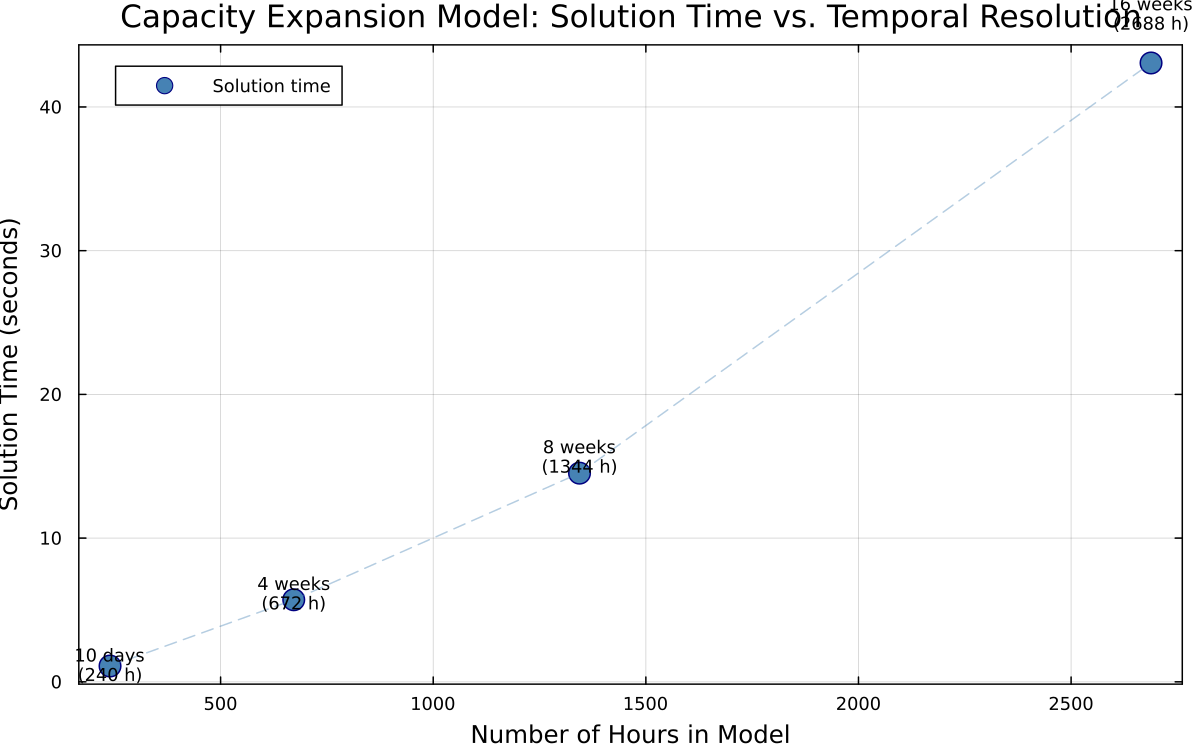

In [28]:
display(p)

As the number of hours in the model goes up the solution time does not increase linearly, the increase appears to be on a more polynomial type of scale of increasing. Especially with the jump from 8 to 16 weeks being particularly steep. The larger the number of hours, the larger multiplier to the solve time, if we were to run the 52 week model, I would expect it to more than double the solve time of the 16 week run, likely running for several minutes. Adding hours increases both number of variables and constraints so it makes sense that the increase in solve time is not simply linear.

#### Question 1(b)

Now let's see how the results of the model compare. Compile tables that compare (i) total cost results, (ii) total final capacity (MW) results by resource, and (iii) the total generation (GWh) results for all four iterations of the model. 

What are the largest differences in results in each category? What do you think accounts for these differences? How would you measure or assess the accuracy of this model? How might this change, depending on the type of question are you are considering? 

In [29]:
# Labels used as column headers in comparison tables
res_labels = [suffix for (_, suffix, _) in resolutions]
n_hours_vec = [n for (_, _, n) in resolutions]

# Result Reading 
function read_result(out_suffix, filename, outputs_dir)
    path = joinpath(outputs_dir, out_suffix, filename)
    return DataFrame(CSV.File(path))
end

# (i) TOTAL COST RESULTS
println("TABLE (i): TOTAL COST RESULTS COMPARISON  (all values in \$M/year)")

cost_dfs = [read_result(suf, "cost_results.csv", outputs_directory_1a) for (_, suf, _) in resolutions]

cost_rows = ["Fixed_Costs_Generation",
             "Fixed_Costs_Storage",
             "Fixed_Costs_Transmission",
             "Variable_Costs",
             "NSE_Costs",
             "Total_Costs"]

cost_comparison = DataFrame(Cost_Component = cost_rows)
for (df, lbl) in zip(cost_dfs, res_labels)
    cost_comparison[!, lbl] = [round(df[1, col], digits=1) for col in cost_rows]
end

# Add a column showing max absolute deviation across resolutions
cost_comparison.Max_Deviation = [
    round(maximum(cost_comparison[i, 2:end]) - minimum(cost_comparison[i, 2:end]), digits=1)
    for i in 1:nrow(cost_comparison)
]

println(cost_comparison)
CSV.write(joinpath(outputs_directory_1a, "comparison_costs.csv"), cost_comparison)
println("\nSaved >> comparison_costs.csv")

# (ii) TOTAL CAPACITY RESULTS TABLE
println("TABLE (ii): TOTAL FINAL CAPACITY (MW) BY RESOURCE")

gen_dfs = [read_result(suf, "generator_results.csv", outputs_directory_1a) for (_, suf, _) in resolutions]

# Use resource names from the first resolution as the index
# (resource set is the same across resolutions)
resource_names = gen_dfs[1].Resource

cap_comparison = DataFrame(Resource = resource_names, Zone = gen_dfs[1].Zone)
for (df, lbl) in zip(gen_dfs, res_labels)
    cap_comparison[!, lbl] = round.(df.Total_MW, digits=1)
end

# Max absolute deviation across resolutions
cap_comparison.Max_Deviation_MW = [
    round(maximum(Vector(cap_comparison[i, 3:3+length(res_labels)-1])) -
          minimum(Vector(cap_comparison[i, 3:3+length(res_labels)-1])), digits=1)
    for i in 1:nrow(cap_comparison)
]

println(cap_comparison)
CSV.write(joinpath(outputs_directory_1a, "comparison_capacity_MW.csv"), cap_comparison)
println("\nSaved >> comparison_capacity_MW.csv")

# (iii) TOTAL GENERATION RSULTS 
println("TABLE (iii): TOTAL GENERATION (GWh) ACROSS ALL FOUR MODEL ITERATIONS")

total_gen_row = [round(sum(df.GWh), digits=1) for df in gen_dfs]

gen_comparison = DataFrame(reshape(total_gen_row, 1, :), res_labels)

println(gen_comparison)
CSV.write(joinpath(outputs_directory_1a, "comparison_generation_GWh.csv"), gen_comparison)
println("\nSaved >> comparison_generation_GWh.csv")


TABLE (i): TOTAL COST RESULTS COMPARISON  (all values in $M/year)
6×6 DataFrame
 Row │ Cost_Component            10_days_cfrank  4_weeks_cfrank  8_weeks_cfrank  16_weeks_cfrank  Max_Deviation 
     │ String                    Float64         Float64         Float64         Float64          Float64       
─────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ Fixed_Costs_Generation            4755.9          4995.4          5186.5           5191.5          435.6
   2 │ Fixed_Costs_Storage                  0.0             0.0             0.0              0.0            0.0
   3 │ Fixed_Costs_Transmission            82.4            37.1           132.4            119.7           95.3
   4 │ Variable_Costs                    9327.9          9407.4          8884.4           8821.3          586.1
   5 │ NSE_Costs                           30.4            34.8            24.6             29.5           10.2
   6 │ Total_Costs   

Variable costs is the category with the largest differences. This likely deals with how well each sample week scenario captures the dispatch information across the seasons of the year being represented. The largest variation is between the 4 and 16 week model being the highest and lowest variable cost results respectively. (with a difference of $417 million) Fixed generation costs vary by a large amount across categories, but that swing of ~$185 million is low relative to the total cost of fixed generation being on the order of $8600 million. Other swings are also small relative to the general order of the results. 

Deviation in capacity is largest for utility PV los angeles, with the largest difference between the 10 day and 16 week trial, this could be due to what periods each trial is pulling from affecting the amount of solar available in that regon and thus swinging the chosen deployment for that technology. Utility pv LA has another swing value along with a natural gas CC, but otherwise the chosen generation capacities are the same across trials, likely a result of the different sets generally capturing the same image, with the base building blocks largely being the same, and only some variation required to reach the final differences. 

For generation, there were no major differences, results across the 4 runs remained relatively stable with a very small spread relative to the order of the results. Variation is again attributable to variation in how each set represents the full year and the variation in seasons. 

Period sampling variation and dispatch errors due to the temporal set choices for sampling are likely to blame for all these variations. Also, the nature of the model means early decisions on capacity at the start of the model can lead to larger variations by the end of the run. Running a full trial for the 52 week run would provide a benchmark to examine variation and create a "ground truth" that could be utilized to assess the accuracy of each of the models ran above. Since some results featured small amounts of variation across trials, determining if the sample size is the primary factor at play, or if the range being sampled is would be relevant while testing. This would also be relevant depending on if the question examines system wide features or more technology/ single resource specificity. 

#### Question 1(c)

The above experiment includes very little new wind or solar capacity additions. Let's try another case, which includes a **carbon tax of $50/tCO2**. 

The `generators` dataset contains information on the CO2 emissions per MWh (tCO2/MWh) in the column `CO2_Rate`.

Create a copy of the capacity expansion function below, name it `solve_cap_expansion_co2`, and modify the following:
- add a new parameter to the function `CO2_Price`
- add an additional expression `eCO2Costs` given by the following expression
- add this new cost to Total Costs

In [30]:
#     @expression(Expansion_Model, eCO2Costs,
#          # Carbon tax costs: variable only
#         sum(sample_weight[t]*generators.CO2_Rate[g]*vGEN[t,g]*CO2_Price for t in T, g in G)
#     )

In [31]:
function solve_cap_expansion_co2(generators, G,
    demand, S, T, Z,
    nse,
    sample_weight, hours_per_period,
    lines, L,
    variability,
    CO2_Price, # NEW carbon tax ($/tCO2)
    solver)

    # SUBSETS
    UC = intersect(generators.R_ID[generators.Commit.==1], G)
    ED = intersect(generators.R_ID[.!(generators.Commit .== 1)], G)
    STOR = intersect(generators.R_ID[generators.STOR.>=1], G)
    VRE = intersect(generators.R_ID[generators.DISP.==1], G)
    NEW = intersect(generators.R_ID[generators.New_Build.==1], G)
    OLD = intersect(generators.R_ID[.!(generators.New_Build .== 1)], G)
    RPS = intersect(generators.R_ID[generators.RPS.==1], G)

    Expansion_Model = Model(solver)

    # DECISION VARIABLES 
    @variables(Expansion_Model, begin
        vCAP[g in G] >= 0
        vRET_CAP[g in OLD] >= 0
        vNEW_CAP[g in NEW] >= 0

        vE_CAP[g in STOR]  >= 0
        vRET_E_CAP[g in intersect(STOR, OLD)] >= 0
        vNEW_E_CAP[g in intersect(STOR, NEW)] >= 0

        vT_CAP[l in L] >= 0
        vRET_T_CAP[l in L] >= 0
        vNEW_T_CAP[l in L] >= 0
    end)

    for g in NEW[generators[NEW, :Max_Cap_MW].>0]
        set_upper_bound(vNEW_CAP[g], generators.Max_Cap_MW[g])
    end
    for l in L
        set_upper_bound(vNEW_T_CAP[l], lines.Line_Max_Reinforcement_MW[l])
    end

    @variables(Expansion_Model, begin
        vGEN[T, G] >= 0
        vCHARGE[T, STOR] >= 0
        vSOC[T, STOR] >= 0
        vNSE[T, S, Z] >= 0
        vFLOW[T, L]
    end)

    # CONSTRAINTS 
    @constraint(Expansion_Model, cDemandBalance[t in T, z in Z],
        sum(vGEN[t, g] for g in intersect(generators[generators.zone.==z, :R_ID], G)) +
        sum(vNSE[t, s, z] for s in S) -
        sum(vCHARGE[t, g] for g in intersect(generators[generators.zone.==z, :R_ID], STOR)) -
        demand[t, z] -
        sum(lines[l, Symbol(string("z", z))] * vFLOW[t, l] for l in L) == 0
    )

    @constraints(Expansion_Model, begin
        cMaxPower[t in T, g in G],
            vGEN[t, g] <= variability[t, g] * vCAP[g]
        cMaxCharge[t in T, g in STOR],
            vCHARGE[t, g] <= vCAP[g]
        cMaxSOC[t in T, g in STOR],
            vSOC[t, g] <= vE_CAP[g]
        cMaxNSE[t in T, s in S, z in Z],
            vNSE[t, s, z] <= nse.NSE_Max[s] * demand[t, z]
        cMaxFlow[t in T, l in L],
            vFLOW[t, l] <= vT_CAP[l]
        cMinFlow[t in T, l in L],
            vFLOW[t, l] >= -vT_CAP[l]
    end)

    @constraints(Expansion_Model, begin
        cCapOld[g in OLD],
            vCAP[g] == generators.Existing_Cap_MW[g] - vRET_CAP[g]
        cCapNew[g in NEW],
            vCAP[g] == vNEW_CAP[g]
        cCapEnergyOld[g in intersect(STOR, OLD)],
            vE_CAP[g] == generators.Existing_Cap_MWh[g] - vRET_E_CAP[g]
        cCapEnergyNew[g in intersect(STOR, NEW)],
            vE_CAP[g] == vNEW_E_CAP[g]
        cTransCap[l in L],
            vT_CAP[l] == lines.Line_Max_Flow_MW[l] - vRET_T_CAP[l] + vNEW_T_CAP[l]
    end)

    STARTS = convert(Array{Int64},
                    1:hours_per_period:floor(maximum(T) / hours_per_period) * hours_per_period)
    INTERIORS = setdiff(T, STARTS)

    @constraints(Expansion_Model, begin
        cRampUp[t in INTERIORS, g in G],
            vGEN[t, g] - vGEN[t-1, g] <= generators.Ramp_Up_percentage[g] * vCAP[g]
        cRampUpWrap[t in STARTS, g in G],
            vGEN[t, g] - vGEN[t+hours_per_period-1, g] <= generators.Ramp_Up_percentage[g] * vCAP[g]
        cRampDown[t in INTERIORS, g in G],
            vGEN[t-1, g] - vGEN[t, g] <= generators.Ramp_Dn_percentage[g] * vCAP[g]
        cRampDownWrap[t in STARTS, g in G],
            vGEN[t+hours_per_period-1, g] - vGEN[t, g] <= generators.Ramp_Dn_percentage[g] * vCAP[g]
        cSOC[t in INTERIORS, g in STOR],
            vSOC[t, g] == vSOC[t-1, g] +
                          generators.Eff_up[g] * vCHARGE[t, g] -
                          vGEN[t, g] / generators.Eff_down[g]
        cSOCWrap[t in STARTS, g in STOR],
            vSOC[t, g] == vSOC[t+hours_per_period-1, g] +
                          generators.Eff_up[g] * vCHARGE[t, g] -
                          vGEN[t, g] / generators.Eff_down[g]
    end)

    # OBJECTIVE FUNCTION
    @expression(Expansion_Model, eFixedCostsGeneration,
        sum(generators.Fixed_OM_cost_per_MWyr[g] * vCAP[g] for g in G) +
        sum(generators.Inv_cost_per_MWyr[g] * vNEW_CAP[g] for g in NEW)
    )

    @expression(Expansion_Model, eFixedCostsStorage,
        sum(generators.Fixed_OM_cost_per_MWhyr[g] * vE_CAP[g] for g in STOR) +
        sum(generators.Inv_cost_per_MWhyr[g] * vNEW_CAP[g] for g in intersect(STOR, NEW))
    )

    @expression(Expansion_Model, eFixedCostsTransmission,
        sum(lines.Line_Fixed_Cost_per_MW_yr[l] * vT_CAP[l] +
            lines.Line_Reinforcement_Cost_per_MW_yr[l] * vNEW_T_CAP[l] for l in L)
    )

    @expression(Expansion_Model, eVariableCosts,
        sum(sample_weight[t] * generators.Var_Cost[g] * vGEN[t, g] for t in T, g in G)
    )

    @expression(Expansion_Model, eNSECosts,
        sum(sample_weight[t] * nse.NSE_Cost[s] * vNSE[t, s, z] for t in T, s in S, z in Z)
    )

    # NEW Carbon tax cost>> CO2_Price ($/tCO2) * CO2_Rate (tCO2/MWh) * generation (MWh)
    @expression(Expansion_Model, eCO2Costs,
        CO2_Price *
        sum(sample_weight[t] * generators.CO2_Rate[g] * vGEN[t, g] for t in T, g in G)
    )

    # NEW eCO2Costs added to total
    @expression(Expansion_Model, eTotalCosts,
        eFixedCostsGeneration + eFixedCostsStorage + eFixedCostsTransmission +
        eVariableCosts + eNSECosts + eCO2Costs
    )

    @objective(Expansion_Model, Min, eTotalCosts)

    # SOLVE
    elapsed_time = @elapsed optimize!(Expansion_Model)

    # EXTRACT RESULTS 
    generation   = zeros(size(G, 1))
    for i in 1:size(G, 1)
        generation[i] = sum(sample_weight .* value.(vGEN)[:, G[i]].data)
    end
    total_demand = sum(sum.(eachcol(sample_weight .* demand)))
    peak_demand = maximum(sum(eachcol(demand)))
    MWh_share = generation ./ total_demand .* 100
    cap_share = value.(vCAP).data ./ peak_demand .* 100

    generator_results = DataFrame(
        ID = G,
        Resource = generators.Resource[G],
        Zone = generators.zone[G],
        Total_MW = value.(vCAP).data,
        Start_MW = generators.Existing_Cap_MW[G],
        Change_in_MW = value.(vCAP).data .- generators.Existing_Cap_MW[G],
        Percent_MW = cap_share,
        GWh = generation / 1000,
        Percent_GWh = MWh_share,
    )

    storage_results = DataFrame(
        ID = STOR,
        Zone = generators.zone[STOR],
        Resource = generators.Resource[STOR],
        Total_Storage_MWh = value.(vE_CAP).data,
        Start_Storage_MWh = generators.Existing_Cap_MWh[STOR],
        Change_in_Storage_MWh = value.(vE_CAP).data .- generators.Existing_Cap_MWh[STOR],
    )

    transmission_results = DataFrame(
        Line = L,
        Total_Transfer_Capacity = value.(vT_CAP).data,
        Start_Transfer_Capacity = lines.Line_Max_Flow_MW,
        Change_in_Transfer_Capacity = value.(vT_CAP).data .- lines.Line_Max_Flow_MW,
    )

    num_segments = maximum(S)
    num_zones = maximum(Z)
    nse_results = DataFrame(
        Segment  = zeros(num_segments * num_zones),
        Zone = zeros(num_segments * num_zones),
        NSE_Price = zeros(num_segments * num_zones),
        Max_NSE_MW = zeros(num_segments * num_zones),
        Total_NSE_MWh  = zeros(num_segments * num_zones),
        NSE_Percent_of_Demand = zeros(num_segments * num_zones),
    )
    i = 1
    for s in S
        for z in Z
            nse_results.Segment[i] = s
            nse_results.Zone[i] = z
            nse_results[!, :NSE_Price] .= nse.NSE_Cost[s]
            nse_results.Max_NSE_MW[i] = maximum(value.(vNSE)[:, s, z].data)
            nse_results.Total_NSE_MWh[i]= sum(sample_weight .* value.(vNSE)[:, s, z].data)
            nse_results.NSE_Percent_of_Demand[i] = sum(sample_weight .* value.(vNSE)[:, s, z].data) /
                                                    total_demand * 100
            i = i + 1
        end
    end

    # [NEW] CO2 costs included in cost_results
    cost_results = DataFrame(
        Fixed_Costs_Generation = value.(eFixedCostsGeneration) / 10^6,
        Fixed_Costs_Storage = value.(eFixedCostsStorage) / 10^6,
        Fixed_Costs_Transmission = value.(eFixedCostsTransmission) / 10^6,
        Variable_Costs = value.(eVariableCosts) / 10^6,
        NSE_Costs = value.(eNSECosts) / 10^6,
        CO2_Costs = value.(eCO2Costs) / 10^6,
        Total_Costs = value.(eTotalCosts) / 10^6,
    )

    return (generator_results,
            storage_results,
            transmission_results,
            nse_results,
            cost_results,
            elapsed_time)
end


solve_cap_expansion_co2 (generic function with 1 method)

Now repeat the experiment in Question 1(a-b) above with the CO2 price, recording solution time and results for 10 days, 4 weeks, 8 weeks, and 16 weeks time series inputs. Save the results to `10_days_CO2_charlie_frank`, etc.

Answer the following questions:

How have the capacity and energy results changed overall with addition of the carbon price to fuel costs (relative to the original cases? 

How does the variation in the cost, capacity, and energy ouputs change now as you consider different number/duration of sample periods?

What does the overall experiment in Question 1 tell you about the generalizability of time sampling methods?

In [32]:
inputs_directory_1c = "/Users/bison/Documents/GitHub/classes/MAE 243/complex_expansion_data"
outputs_directory_1c = "/Users/bison/Documents/GitHub/classes/MAE 243/hw5_1c_results"
CO2_PRICE = 50.0

if !(isdir(outputs_directory_1c))
    mkdir(outputs_directory_1c)
end

# TESTS 
resolutions = [
    ("10_days", "10_days_CO2_Charlie_Frank", 240),
    ("4_weeks", "4_weeks_CO2_Charlie_Frank", 672),
    ("8_weeks", "8_weeks_CO2_Charlie_Frank", 1344),
    ("16_weeks", "16_weeks_CO2_Charlie_Frank", 2688),
]

# Collect results for the scatter plot
hours_vec = Int[]
times_vec = Float64[]

# Testing loop
for (period_folder, out_suffix, n_hours) in resolutions

    println("Running model: $period_folder  ($n_hours hours)")

    inputs_path = joinpath(inputs_directory_1c, period_folder)

    # Load inputs
    (generators, G) = load_input_generator(inputs_path)
    (demand, nse, sample_weight, hours_per_period, P, S, W, T, Z) = load_input_demand(inputs_path)
    variability  = load_input_variability(inputs_path)
    (lines, L) = load_input_network(inputs_path)

    # Solve model
    (generator_results,
     storage_results,
     transmission_results,
     nse_results,
     cost_results,
     elapsed_time) = solve_cap_expansion_co2(generators, G,
                                         demand, S, T, Z,
                                         nse,
                                         sample_weight, hours_per_period,
                                         lines, L,
                                         variability,CO2_PRICE ,Gurobi.Optimizer)

    elapsed_time = round(elapsed_time, digits = 2)
    println("Solution time for $period_folder: $elapsed_time seconds")

    # Write results
    out_path = joinpath(outputs_directory_1c, out_suffix)
    write_results(generator_results,
                  storage_results,
                  transmission_results,
                  nse_results,
                  cost_results,
                  elapsed_time,
                  out_path)

    push!(hours_vec, n_hours)
    push!(times_vec, elapsed_time)
end

Running model: 10_days  (240 hours)
Set parameter Username
Set parameter LicenseID to value 2828482
Academic license - for non-commercial use only - expires 2027-05-28
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: 11th Gen Intel(R) Core(TM) i7-1165G7 @ 2.80GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 42777 rows, 15956 columns and 123396 nonzeros (Min)
Model fingerprint: 0xd38ea795
Model has 6338 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e-04, 4e+00]
  Objective range  [1e+01, 6e+05]
  Bounds range     [8e+02, 9e+04]
  RHS range        [1e+02, 9e+04]

Presolve removed 5819 rows and 2249 columns
Presolve time: 0.10s
Presolved: 12647 rows, 37883 columns, 125906 nonzeros

Concurrent LP optimizer: dual simplex and barrier
Showing barrier log only...

Ordering time: 0.04s

Barrier statistics:
 Free vars  : 307
 AA'


Scatter plot saved to: /Users/bison/Documents/GitHub/classes/MAE 243/hw5_1c_results\solution_time_vs_hours.png


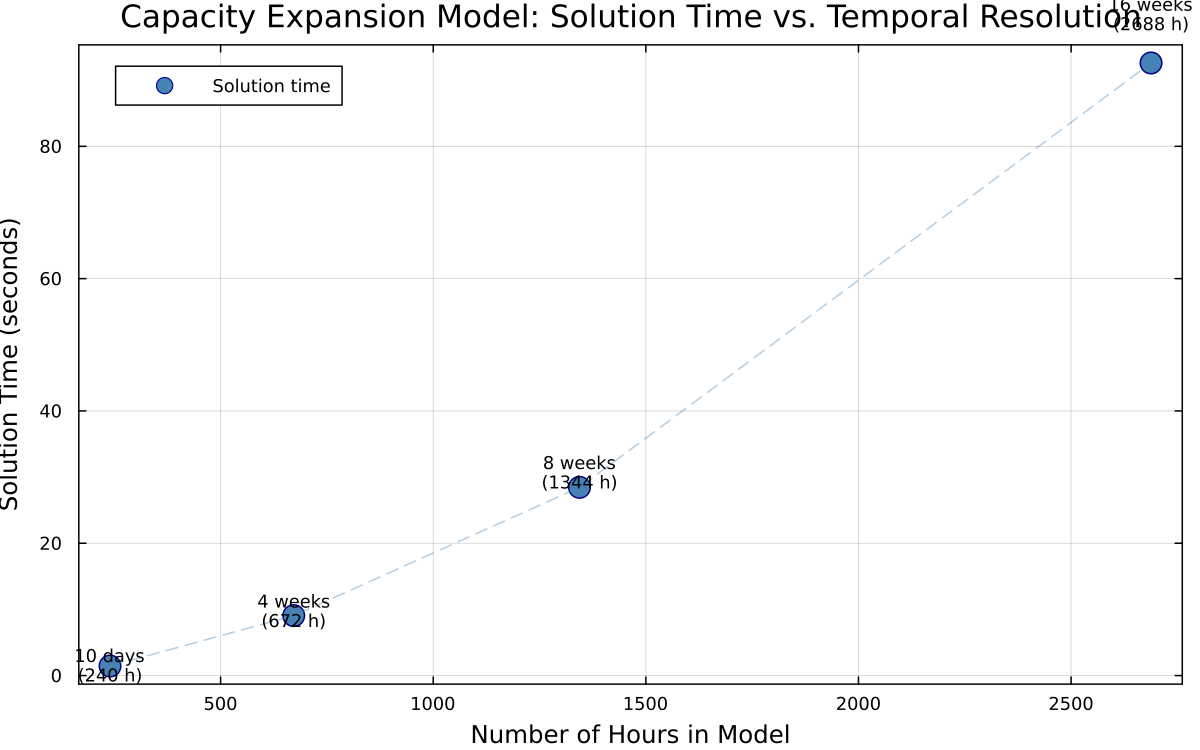

In [33]:
# SCATTER PLOT

labels = ["10 days\n(240 h)", "4 weeks\n(672 h)", "8 weeks\n(1344 h)", "16 weeks\n(2688 h)"]

p2 = scatter(hours_vec, times_vec,
    xlabel = "Number of Hours in Model",
    ylabel = "Solution Time (seconds)",
    title = "Capacity Expansion Model: Solution Time vs. Temporal Resolution",
    label = "Solution time",
    markersize = 8,
    markercolor = :steelblue,
    markerstrokewidth = 1,
    markerstrokecolor = :navy,
    legend = :topleft,
    grid = true,
    framestyle = :box,
    dpi = 150,
    size = (800, 500),
)

# Annotate each point with its period label
for (x, y, lbl) in zip(hours_vec, times_vec, labels)
    annotate!(p2, x, y * 1.08, text(lbl, 8, :center, :black))
end

# Connecting line
plot!(p2, hours_vec, times_vec,
    linecolor = :steelblue,
    linealpha = 0.4,
    linestyle = :dash,
    label = false,
)

plot_path = joinpath(outputs_directory_1c, "solution_time_vs_hours.png")
savefig(p2, plot_path)
println("\nScatter plot saved to: $plot_path")
display(p2)

In [34]:
# Labels used as column headers in comparison tables
res_labels = [suffix for (_, suffix, _) in resolutions]
n_hours_vec = [n for (_, _, n) in resolutions]

function read_result(out_suffix, filename, outputs_dir)
    path = joinpath(outputs_dir, out_suffix, filename)
    return DataFrame(CSV.File(path))
end

# (i) TOTAL COST RESULTS
println("TABLE (i): TOTAL COST RESULTS COMPARISON  (all values in \$M/year)")

cost_dfs = [read_result(suf, "cost_results.csv", outputs_directory_1c) for (_, suf, _) in resolutions]

cost_rows = ["Fixed_Costs_Generation",
             "Fixed_Costs_Storage",
             "Fixed_Costs_Transmission",
             "Variable_Costs",
             "NSE_Costs",
             "Total_Costs"]

cost_comparison = DataFrame(Cost_Component = cost_rows)
for (df, lbl) in zip(cost_dfs, res_labels)
    cost_comparison[!, lbl] = [round(df[1, col], digits=1) for col in cost_rows]
end

# Add a column showing max absolute deviation across resolutions
cost_comparison.Max_Deviation = [
    round(maximum(cost_comparison[i, 2:end]) - minimum(cost_comparison[i, 2:end]), digits=1)
    for i in 1:nrow(cost_comparison)
]

println(cost_comparison)
CSV.write(joinpath(outputs_directory_1c, "comparison_costs.csv"), cost_comparison)
println("\nSaved >> comparison_costs.csv")

# (ii) TOTAL CAPACITY RESULTS
println("TABLE (ii): TOTAL FINAL CAPACITY (MW) BY RESOURCE")

gen_dfs = [read_result(suf, "generator_results.csv", outputs_directory_1c) for (_, suf, _) in resolutions]

# Use resource names from the first resolution as the index
# (resource set is the same across resolutions)
resource_names = gen_dfs[1].Resource

cap_comparison = DataFrame(Resource = resource_names, Zone = gen_dfs[1].Zone)
for (df, lbl) in zip(gen_dfs, res_labels)
    cap_comparison[!, lbl] = round.(df.Total_MW, digits=1)
end

# Max absolute deviation across resolutions
cap_comparison.Max_Deviation_MW = [
    round(maximum(Vector(cap_comparison[i, 3:3+length(res_labels)-1])) -
          minimum(Vector(cap_comparison[i, 3:3+length(res_labels)-1])), digits=1)
    for i in 1:nrow(cap_comparison)
]

println(cap_comparison)
CSV.write(joinpath(outputs_directory_1c, "comparison_capacity_MW.csv"), cap_comparison)
println("\nSaved >> comparison_capacity_MW.csv")

# (iii) TOTAL GENERATION RSULTS 
println("TABLE (iii): TOTAL GENERATION (GWh) ACROSS ALL FOUR MODEL ITERATIONS")

total_gen_row = [round(sum(df.GWh), digits=1) for df in gen_dfs]

gen_comparison = DataFrame(reshape(total_gen_row, 1, :), res_labels)

println(gen_comparison)
CSV.write(joinpath(outputs_directory_1c, "comparison_generation_GWh.csv"), gen_comparison)
println("\nSaved >> comparison_generation_GWh.csv")


TABLE (i): TOTAL COST RESULTS COMPARISON  (all values in $M/year)
6×6 DataFrame
 Row │ Cost_Component            10_days_CO2_cfrank  4_weeks_CO2_cfrank  8_weeks_CO2_cfrank  16_weeks_CO2_cfrank  Max_Deviation 
     │ String                    Float64             Float64             Float64             Float64              Float64       
─────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ Fixed_Costs_Generation                8773.2              8587.8              8683.1               8630.4          185.4
   2 │ Fixed_Costs_Storage                      9.5                19.3                25.7                 15.0           16.2
   3 │ Fixed_Costs_Transmission               161.9                66.6               172.9                164.8          106.3
   4 │ Variable_Costs                        6334.1              6785.5              6426.0               6368.8          451.4
   5 │ NSE_Costs     

The capacity and energy results with the carbon price of fuel costs are different in some major ways to the original cases. The total generation has increased for every trial relative to the original, which makes sense as the carbon price encourages more renewables that will overproduce in certain parts of the day for systems that need to cover demand throughout the day even when renewable production is lower overnight due to the lack of solar. Capacity for coal was completely removed, with decreases also occuring for combined cycle natural gas. This also marks the entry of batteries into the capacity mix, which makes sense as the system will try to avoid curtailment. These results all make sense as the carbon price discourages highly polluting generators and encourages the utilization of more energy from renewables or cleaner fossils to meet demand needs. 

For these results, we see variation in cost increase across trials, with the largest change being $570 million between the 4 and 16 week trials again. Generally the trials all vary between each other in similar ways to the original run, just with different magnitudes, this time around for costs fixed gen costs and variable costs are down relative to the original model, while every other price is up. NSE is significantly higher, which is a bad sign for the performance of this modelled system if we want to realistically run the grid off this capacity plan.
For capacity the variation generally sees solar and gas trade places across the different temporal sets. This is likely due to some sets having higher solar availability and thus making it a more reasonable investment. In sets with high solar like the 10 day trial, we see gas is the lowest of the 4 trials by almost 10000 MW, with solar the highest of the 4. In the 16 week trial, presumptively the solar availability is a bit more realistic and not swung by the occasional high solar day, making the model more cautious toward solar expansion and relying on natural gas more even with the CO2 cost. 
Total energy production is up relative to the original, with variation across sets once again likely explained by small variations in resource availability and slight differences in the temporal sets, we see the values are still fairly close to their original terms despite the capacity mix changing dramatically compared to the original model. 

The overall experiment in quesiton 1 demonstrates that aggregate outcomes are generally robust across temporal resolutions, but marginal decisions like the deployment of solar versus firm tech like natural gas are not. Time sampling methods can generalize well for system wide information and accounting, but specificity of deployment really requires a higher resolution if you wish to properly paint the picture of the system you are modelling. 


### Part 2: Clean electricity standard policy

For this question, in a new function `solve_cap_expansion_ces`, implement a clean electricity standard (CES) policy--a constraint that requires a certain share of generation from clean sources. Eligibility for a clean electricity standard is also recorded in the `generators.CES[g]` parameter and includes wind, solar, nuclear, generators with CCS, and hydro (not present).

Take care in your implementation to consider the role of time weights when using a reduced time series as we are here (not all hours are created equal!).

Run your capacity planning model with 8 weeks of data and under increasing stringency (e.g. at 0%, 20%, 40%, 60%, 80% and 100% clean energy requirement), and record and discuss results of each case. 

What do you notice about solution time and results as you change the stringency of the policy? How much does the policy increase costs at each level of stringency, relative to no policy? How much does it reduce CO$_2$ emissions? (You will need to add a calculation of CO$_2$ emissions to the model outputs recorded using `CO2_Rate`.)

In [53]:
function solve_cap_expansion_ces(generators, G,
    demand, S, T, Z,
    nse,
    sample_weight, hours_per_period,
    lines, L,
    variability,
    CES_Share, # NEW required fraction of total generation from CES resources (0–1)
    solver)

    # SUBSETS
    UC = intersect(generators.R_ID[generators.Commit.==1], G)
    STOR = intersect(generators.R_ID[generators.STOR.>=1], G)
    VRE = intersect(generators.R_ID[generators.DISP.==1], G)
    NEW = intersect(generators.R_ID[generators.New_Build.==1], G)
    OLD = intersect(generators.R_ID[.!(generators.New_Build .== 1)], G)
    RPS = intersect(generators.R_ID[generators.RPS.==1], G)
    # NEW CES eligible resources: wind, solar, nuclear, CCS 
    CES  = intersect(generators.R_ID[generators.CES.==1], G)

    Expansion_Model = Model(solver)

    #DECISION VARIABLES 
    @variables(Expansion_Model, begin
        vCAP[g in G] >= 0
        vRET_CAP[g in OLD] >= 0
        vNEW_CAP[g in NEW] >= 0

        vE_CAP[g in STOR] >= 0
        vRET_E_CAP[g in intersect(STOR, OLD)]  >= 0
        vNEW_E_CAP[g in intersect(STOR, NEW)]  >= 0

        vT_CAP[l in L] >= 0
        vRET_T_CAP[l in L] >= 0
        vNEW_T_CAP[l in L] >= 0
    end)

    for g in NEW[generators[NEW, :Max_Cap_MW].>0]
        set_upper_bound(vNEW_CAP[g], generators.Max_Cap_MW[g])
    end
    for l in L
        set_upper_bound(vNEW_T_CAP[l], lines.Line_Max_Reinforcement_MW[l])
    end

    @variables(Expansion_Model, begin
        vGEN[T, G] >= 0
        vCHARGE[T, STOR] >= 0
        vSOC[T, STOR] >= 0
        vNSE[T, S, Z] >= 0
        vFLOW[T, L]
    end)

    # CONSTRAINTS 
    @constraint(Expansion_Model, cDemandBalance[t in T, z in Z],
        sum(vGEN[t, g] for g in intersect(generators[generators.zone.==z, :R_ID], G)) +
        sum(vNSE[t, s, z] for s in S) -
        sum(vCHARGE[t, g] for g in intersect(generators[generators.zone.==z, :R_ID], STOR)) -
        demand[t, z] -
        sum(lines[l, Symbol(string("z", z))] * vFLOW[t, l] for l in L) == 0
    )

    @constraints(Expansion_Model, begin
        cMaxPower[t in T, g in G],
            vGEN[t, g] <= variability[t, g] * vCAP[g]
        cMaxCharge[t in T, g in STOR],
            vCHARGE[t, g] <= vCAP[g]
        cMaxSOC[t in T, g in STOR],
            vSOC[t, g] <= vE_CAP[g]
        cMaxNSE[t in T, s in S, z in Z],
            vNSE[t, s, z] <= nse.NSE_Max[s] * demand[t, z]
        cMaxFlow[t in T, l in L],
            vFLOW[t, l] <= vT_CAP[l]
        cMinFlow[t in T, l in L],
            vFLOW[t, l] >= -vT_CAP[l]
    end)

    @constraints(Expansion_Model, begin
        cCapOld[g in OLD],
            vCAP[g] == generators.Existing_Cap_MW[g] - vRET_CAP[g]
        cCapNew[g in NEW],
            vCAP[g] == vNEW_CAP[g]
        cCapEnergyOld[g in intersect(STOR, OLD)],
            vE_CAP[g] == generators.Existing_Cap_MWh[g] - vRET_E_CAP[g]
        cCapEnergyNew[g in intersect(STOR, NEW)],
            vE_CAP[g] == vNEW_E_CAP[g]
        cTransCap[l in L],
            vT_CAP[l] == lines.Line_Max_Flow_MW[l] - vRET_T_CAP[l] + vNEW_T_CAP[l]
    end)

    STARTS = convert(Array{Int64},
                    1:hours_per_period:floor(maximum(T) / hours_per_period) * hours_per_period)
    INTERIORS = setdiff(T, STARTS)

    @constraints(Expansion_Model, begin
        cRampUp[t in INTERIORS, g in G],
            vGEN[t, g] - vGEN[t-1, g] <= generators.Ramp_Up_percentage[g] * vCAP[g]
        cRampUpWrap[t in STARTS, g in G],
            vGEN[t, g] - vGEN[t+hours_per_period-1, g] <= generators.Ramp_Up_percentage[g] * vCAP[g]
        cRampDown[t in INTERIORS, g in G],
            vGEN[t-1, g] - vGEN[t, g] <= generators.Ramp_Dn_percentage[g] * vCAP[g]
        cRampDownWrap[t in STARTS, g in G],
            vGEN[t+hours_per_period-1, g] - vGEN[t, g] <= generators.Ramp_Dn_percentage[g] * vCAP[g]
        cSOC[t in INTERIORS, g in STOR],
            vSOC[t, g] == vSOC[t-1, g] +
                          generators.Eff_up[g] * vCHARGE[t, g] -
                          vGEN[t, g] / generators.Eff_down[g]
        cSOCWrap[t in STARTS, g in STOR],
            vSOC[t, g] == vSOC[t+hours_per_period-1, g] +
                          generators.Eff_up[g] * vCHARGE[t, g] -
                          vGEN[t, g] / generators.Eff_down[g]
    end)

    # NEW Clean Electricity Standard constraint
    # Weighted CES generation >= CES_Share × weighted total generation
    @constraint(Expansion_Model, cCES,
        sum(sample_weight[t] * vGEN[t, g] for t in T, g in CES) >=
        CES_Share *
        sum(sample_weight[t] * vGEN[t, g] for t in T, g in G)
    )

    # OBJECTIVE FUNCTION
    @expression(Expansion_Model, eFixedCostsGeneration,
        sum(generators.Fixed_OM_cost_per_MWyr[g] * vCAP[g] for g in G) +
        sum(generators.Inv_cost_per_MWyr[g] * vNEW_CAP[g] for g in NEW)
    )

    @expression(Expansion_Model, eFixedCostsStorage,
        sum(generators.Fixed_OM_cost_per_MWhyr[g] * vE_CAP[g] for g in STOR) +
        sum(generators.Inv_cost_per_MWhyr[g] * vNEW_CAP[g] for g in intersect(STOR, NEW))
    )

    @expression(Expansion_Model, eFixedCostsTransmission,
        sum(lines.Line_Fixed_Cost_per_MW_yr[l] * vT_CAP[l] +
            lines.Line_Reinforcement_Cost_per_MW_yr[l] * vNEW_T_CAP[l] for l in L)
    )

    @expression(Expansion_Model, eVariableCosts,
        sum(sample_weight[t] * generators.Var_Cost[g] * vGEN[t, g] for t in T, g in G)
    )

    @expression(Expansion_Model, eNSECosts,
        sum(sample_weight[t] * nse.NSE_Cost[s] * vNSE[t, s, z] for t in T, s in S, z in Z)
    )

    @expression(Expansion_Model, eTotalCosts,
        eFixedCostsGeneration + eFixedCostsStorage + eFixedCostsTransmission +
        eVariableCosts + eNSECosts
    )

    @objective(Expansion_Model, Min, eTotalCosts)

    # SOLVE
    elapsed_time = @elapsed optimize!(Expansion_Model)

    # EXTRACT RESULTS
    generation   = zeros(size(G, 1))
    for i in 1:size(G, 1)
        generation[i] = sum(sample_weight .* value.(vGEN)[:, G[i]].data)
    end
    total_demand = sum(sum.(eachcol(sample_weight .* demand)))
    peak_demand = maximum(sum(eachcol(demand)))
    MWh_share = generation ./ total_demand .* 100
    cap_share = value.(vCAP).data ./ peak_demand .* 100

    # Realised CES share (for verification)
    ces_gen = sum(generation[i] for i in 1:size(G,1) if G[i] in CES)
    total_gen = sum(generation)
    actual_ces_share = ces_gen / total_gen

    generator_results = DataFrame(
        ID = G,
        Resource = generators.Resource[G],
        Zone = generators.zone[G],
        Total_MW = value.(vCAP).data,
        Start_MW = generators.Existing_Cap_MW[G],
        Change_in_MW = value.(vCAP).data .- generators.Existing_Cap_MW[G],
        Percent_MW = cap_share,
        GWh = generation / 1000,
        Percent_GWh  = MWh_share,
    )

    storage_results = DataFrame(
        ID = STOR,
        Zone = generators.zone[STOR],
        Resource = generators.Resource[STOR],
        Total_Storage_MWh = value.(vE_CAP).data,
        Start_Storage_MWh = generators.Existing_Cap_MWh[STOR],
        Change_in_Storage_MWh = value.(vE_CAP).data .- generators.Existing_Cap_MWh[STOR],
    )

    transmission_results = DataFrame(
        Line = L,
        Total_Transfer_Capacity = value.(vT_CAP).data,
        Start_Transfer_Capacity = lines.Line_Max_Flow_MW,
        Change_in_Transfer_Capacity = value.(vT_CAP).data .- lines.Line_Max_Flow_MW,
    )

    num_segments = maximum(S)
    num_zones = maximum(Z)
    nse_results = DataFrame(
        Segment = zeros(num_segments * num_zones),
        Zone = zeros(num_segments * num_zones),
        NSE_Price = zeros(num_segments * num_zones),
        Max_NSE_MW = zeros(num_segments * num_zones),
        Total_NSE_MWh = zeros(num_segments * num_zones),
        NSE_Percent_of_Demand = zeros(num_segments * num_zones),
    )
    i = 1
    for s in S
        for z in Z
            nse_results.Segment[i]  = s
            nse_results.Zone[i] = z
            nse_results[!, :NSE_Price] .= nse.NSE_Cost[s]
            nse_results.Max_NSE_MW[i] = maximum(value.(vNSE)[:, s, z].data)
            nse_results.Total_NSE_MWh[i] = sum(sample_weight .* value.(vNSE)[:, s, z].data)
            nse_results.NSE_Percent_of_Demand[i] = sum(sample_weight .* value.(vNSE)[:, s, z].data) /
                                                    total_demand * 100
            i = i + 1
        end
    end

    cost_results = DataFrame(
        CES_Share_Required = CES_Share,
        CES_Share_Actual = round(actual_ces_share, digits=4),
        Fixed_Costs_Generation = value.(eFixedCostsGeneration) / 10^6,
        Fixed_Costs_Storage = value.(eFixedCostsStorage) / 10^6,
        Fixed_Costs_Transmission = value.(eFixedCostsTransmission) / 10^6,
        Variable_Costs = value.(eVariableCosts) / 10^6,
        NSE_Costs = value.(eNSECosts) / 10^6,
        Total_Costs = value.(eTotalCosts)  / 10^6,
    )

    return (generator_results,
            storage_results,
            transmission_results,
            nse_results,
            cost_results,
            elapsed_time)
end

solve_cap_expansion_ces (generic function with 1 method)

In [54]:
ces_levels = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
ces_labels = ["CES_$(round(Int, s*100))pct" for s in ces_levels]
inputs_directory_2 = "/Users/bison/Documents/GitHub/classes/MAE 243/complex_expansion_data"
outputs_directory_2 = "/Users/bison/Documents/GitHub/classes/MAE 243/hw5_2_results"
# Load 8-week inputs once (shared across all CES runs)
inputs_path_8w = joinpath(inputs_directory_2, "8_weeks")

(gen_8w, G_8w)  = load_input_generator(inputs_path_8w)
(dem_8w, nse_8w, sw_8w, hpp_8w, P_8w, S_8w, W_8w, T_8w, Z_8w) = load_input_demand(inputs_path_8w)
var_8w = load_input_variability(inputs_path_8w)
(lines_8w, L_8w) = load_input_network(inputs_path_8w)

# Containers for comparison tables
ces_cost_dfs = []
ces_gen_dfs = []

for (ces, lbl) in zip(ces_levels, ces_labels)
    println("CES run: $(round(Int, ces*100))%  ($lbl)")

    (gr, sr, tr, nr, cr, et) = solve_cap_expansion_ces(
        gen_8w, G_8w,
        dem_8w, S_8w, T_8w, Z_8w,
        nse_8w,
        sw_8w, hpp_8w,
        lines_8w, L_8w,
        var_8w,
        ces,
        Gurobi.Optimizer)

    println("  Solution time: $(round(et, digits=2)) s")
    println("  CES required: $(round(Int, ces*100))%")
    println("  CES actual: $(round(cr.CES_Share_Actual[1]*100, digits=2))%")
    println("  Total cost: \$$(round(cr.Total_Costs[1], digits=1))M/yr")

    out_path_2 = joinpath(outputs_directory_2,"8_weeks_$(lbl)_Charlie_Frank")
    write_results(gr, sr, tr, nr, cr, round(et, digits=2), out_path_2)

    push!(ces_cost_dfs, cr)
    push!(ces_gen_dfs,  gr)
end

CES run: 0%  (CES_0pct)
Set parameter Username
Set parameter LicenseID to value 2828482
Academic license - for non-commercial use only - expires 2027-05-28
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: 11th Gen Intel(R) Core(TM) i7-1165G7 @ 2.80GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 239290 rows, 88820 columns and 738632 nonzeros (Min)
Model fingerprint: 0xbc7b0eb6
Model has 35042 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e-04, 1e+01]
  Objective range  [1e+01, 4e+05]
  Bounds range     [8e+02, 9e+04]
  RHS range        [1e+02, 9e+04]

Presolve removed 33053 rows and 10485 columns
Presolve time: 0.72s
Presolved: 73254 rows, 213319 columns, 690136 nonzeros

Concurrent LP optimizer: dual simplex and barrier
Showing barrier log only...

Ordering time: 0.52s

Barrier statistics:
 Free vars  : 2353
 AA' NZ   

In [63]:
# COMPARISON TABLES

# (i) Cost results across CES levels
println("TABLE (i): COST RESULTS BY CES LEVEL  (all values in \$M/year)")

cost_rows_ces = ["Fixed_Costs_Generation", "Fixed_Costs_Storage",
                 "Fixed_Costs_Transmission", "Variable_Costs",
                 "NSE_Costs", "Total_Costs"]

cost_table_ces = DataFrame(Cost_Component = cost_rows_ces)
for (df, lbl) in zip(ces_cost_dfs, ces_labels)
    cost_table_ces[!, lbl] = [round(df[1, col], digits=1) for col in cost_rows_ces]
end
println(cost_table_ces)
CSV.write(joinpath(outputs_directory_2, "ces_comparison_costs.csv"), cost_table_ces)
println("Saved >> ces_comparison_costs.csv")

# (ii) Final capacity (MW) by resource across CES levels
println("TABLE (ii): FINAL CAPACITY (MW) BY RESOURCE AND CES LEVEL")

cap_table_ces = DataFrame(Resource = ces_gen_dfs[1].Resource,
                           Zone     = ces_gen_dfs[1].Zone)
for (df, lbl) in zip(ces_gen_dfs, ces_labels)
    cap_table_ces[!, lbl] = round.(df.Total_MW, digits=1)
end
println(cap_table_ces)
CSV.write(joinpath(outputs_directory_2, "ces_comparison_capacity_MW.csv"), cap_table_ces)
println("Saved >> ces_comparison_capacity_MW.csv")

# (iii) TOTAL GENERATION RESULTS
println("TABLE (iii): TOTAL GENERATION (GWh) ACROSS ALL SIX CES LEVELS")

total_gen_row = [round(sum(df.GWh), digits=1) for df in ces_gen_dfs]

gen_table_ces = DataFrame(reshape(total_gen_row, 1, :), ces_labels)

println(gen_table_ces)
CSV.write(joinpath(outputs_directory_2, "ces_comparison_generation_GWh.csv"), gen_table_ces)
println("\nSaved >> ces_comparison_generation_GWh.csv")

TABLE (i): COST RESULTS BY CES LEVEL  (all values in $M/year)
6×7 DataFrame
 Row │ Cost_Component            CES_0pct  CES_20pct  CES_40pct  CES_60pct  CES_80pct  CES_100pct 
     │ String                    Float64   Float64    Float64    Float64    Float64    Float64    
─────┼────────────────────────────────────────────────────────────────────────────────────────────
   1 │ Fixed_Costs_Generation      5186.5     5186.5     5857.3     9765.0    12158.9     18669.2
   2 │ Fixed_Costs_Storage            0.0        0.0        0.0       81.9        6.2         0.0
   3 │ Fixed_Costs_Transmission     132.4      132.4      152.3      225.1      219.0       253.5
   4 │ Variable_Costs              8884.4     8884.4     8257.8     5688.6     6847.9      9180.3
   5 │ NSE_Costs                     24.6       24.6       23.6       19.1       14.6       403.1
   6 │ Total_Costs                14227.9    14227.9    14291.0    15779.7    19246.5     28506.0
Saved >> ces_comparison_costs.csv
TABLE

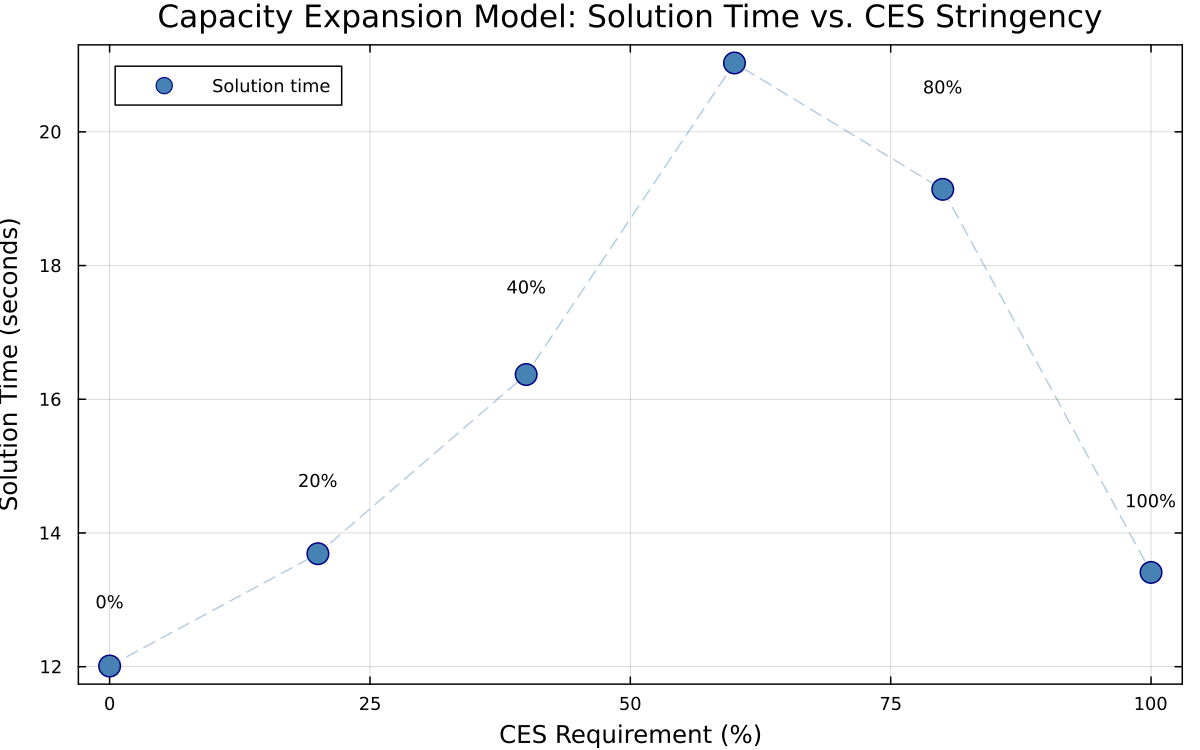

In [59]:
# Read solution times from the written time_results.csv files
ces_elapsed_times = [
    DataFrame(CSV.File(joinpath(outputs_directory_2, "8_weeks_$(lbl)_Charlie_Frank", "time_results.csv"))).time[1]
    for lbl in ces_labels
]

ces_pct = round.(Int, ces_levels .* 100)

Plots.closeall()

p_ces_time = scatter(ces_pct, ces_elapsed_times,
    xlabel            = "CES Requirement (%)",
    ylabel            = "Solution Time (seconds)",
    title             = "Capacity Expansion Model: Solution Time vs. CES Stringency",
    label             = "Solution time",
    markersize        = 8,
    markercolor       = :steelblue,
    markerstrokewidth = 1,
    markerstrokecolor = :navy,
    legend            = :topleft,
    grid              = true,
    framestyle        = :box,
    dpi               = 150,
    size              = (800, 500),
)

for (x, y, lbl) in zip(ces_pct, ces_elapsed_times, ["$(p)%" for p in ces_pct])
    annotate!(p_ces_time, x, y * 1.08, text(lbl, 8, :center, :black))
end

plot!(p_ces_time, ces_pct, ces_elapsed_times,
    linecolor = :steelblue,
    linealpha = 0.4,
    linestyle = :dash,
    label     = false,
)

savefig(p_ces_time, joinpath(outputs_directory_2, "ces_solution_time_vs_share.png"))
display(p_ces_time)

The 0% and 20% cases are identical. Beyond that, costs rise slowly at first then accelerate sharply, doubling at 100% CES, driven by massive new CCS investment needed to cover all hours without fossil fuels.
CO2 reductions follow the same pattern, flat through 20%, middle at 40%, then steep as coal retires at higher %, reaching 95% reduction at 100%. The remaining 5% comes from CCS leakage.
Solve time peaks at 60% then falls towards 100% the feasible region is so constrained the solver finds the solution quickly. Cost effectiveness also degrades sharply. The first 60 percentage points of reduction cost ~$28/tCO2, while the final stretch to 100% costs ~$290/tCO2 — ten times more expensive per unit of abatement.

## Question 3: LLM Exercise

We will explore the impact of varying CO2 price on the model results and solution times. Create
a new section at the end of your Homework notebook titled “Question 3: LLM Exercise”. Include
the LLM prompts used (as markdown text cells in your notebook) and ensure all code is replicated
in the notebook (i.e., do not have the LLM run the code or perform any computation outside of
the notebook).

a) Run the CO2 price model for carbon prices 0 up to $200/t in $50 increments

b) Plot the resulting renewable energy and storage capacities, and plot the solution times

c) What do you observe as CO2 price rises in terms of its effects on renewable energy outcomes?

d) Explore this by plotting generation shares for each of the clean resources as a function of CO2
price.

I utilized Claude Sonnet 4.6 for this portion of the assignment, the free version 
I uploaded the HTML version of my code thus far to provide context for the assignment, my prompt was an attachment of the file with prompt:

**Utilize the attached file as a guideline for code generation for a project I am working on. Using the file and my prompts I want you to generate code that achieves my goals**

I then uploaded the question 4 prompt sans instructions about formatting of the prompt and results, the prompt was as follows:

**We will explore the impact of varying CO2 price on the model results and solution times. a) Run the CO2 price model for carbon prices 0 up to $200/t in $50 increments b) Plot the resulting renewable energy and storage capacities, and plot the solution times d) Explore this by plotting generation shares for each of the clean resources as a function of CO2 price.**

This produced the code you see below (1 block with setup solving and graphing), 

In [67]:
# ── (a) SETUP ────────────────────────────────────────────────────────────────

co2_prices = collect(0:50:200)   # [0, 50, 100, 150, 200] $/tCO2
inputs_directory = "/Users/bison/Documents/GitHub/classes/MAE 243/complex_expansion_data"
outputs_directory = "/Users/bison/Documents/GitHub/classes/MAE 243/hw5_3_results"

# Load 10-day inputs once
inputs_path_10d = joinpath(inputs_directory, "10_days")

(gen_sw, G_sw)                                                    = load_input_generator(inputs_path_10d)
(dem_sw, nse_sw, sw_sw, hpp_sw, P_sw, S_sw, W_sw, T_sw, Z_sw)   = load_input_demand(inputs_path_10d)
var_sw                                                             = load_input_variability(inputs_path_10d)
(lines_sw, L_sw)                                                  = load_input_network(inputs_path_10d)

# Identify resource subsets from loaded generator data (for labelling plots)
VRE_ids  = intersect(gen_sw.R_ID[gen_sw.DISP .== 1],  G_sw)   # wind + solar
STOR_ids = intersect(gen_sw.R_ID[gen_sw.STOR .>= 1],  G_sw)   # storage
CES_ids  = intersect(gen_sw.R_ID[gen_sw.CES  .== 1],  G_sw)   # all clean resources

vre_names  = gen_sw.Resource[VRE_ids]
stor_names = gen_sw.Resource[STOR_ids]
ces_names  = gen_sw.Resource[CES_ids]

# Containers
elapsed_times   = Float64[]
gen_results_all = []   # generator_results DataFrame per run
stor_results_all = []  # storage_results DataFrame per run

# ── RUN SWEEP ────────────────────────────────────────────────────────────────
for co2 in co2_prices

    println("\n" * "="^55)
    println("CO2 price: \$$co2/tCO2")
    println("="^55)

    (gr, sr, tr, nr, cr, et) = solve_cap_expansion_co2(
        gen_sw, G_sw,
        dem_sw, S_sw, T_sw, Z_sw,
        nse_sw,
        sw_sw, hpp_sw,
        lines_sw, L_sw,
        var_sw,
        Float64(co2),
        Gurobi.Optimizer)

    println("  Solution time: $(round(et, digits=2)) s")
    println("  Total cost:    \$$(round(cr.Total_Costs[1], digits=1))M/yr")

    push!(elapsed_times,    et)
    push!(gen_results_all,  gr)
    push!(stor_results_all, sr)

    out_path = joinpath(outputs_directory, "co2_$(co2)_Charlie_Frank")
    write_results(gr, sr, tr, nr, cr, round(et, digits=2), out_path)
end

# ── (b) PLOT 1: Renewable capacity (MW) by resource vs. CO2 price ─────────────

# Build matrix: rows = co2_prices, cols = VRE resources (summed across zones)
vre_cap_matrix = zeros(length(co2_prices), length(vre_names))
for (i, gr) in enumerate(gen_results_all)
    for (j, name) in enumerate(vre_names)
        rows = gr[gr.Resource .== name, :]
        vre_cap_matrix[i, j] = sum(rows.Total_MW)
    end
end

p_vre = plot(co2_prices, vre_cap_matrix,
    label        = reshape(vre_names, 1, :),
    xlabel       = "CO₂ Price (\$/tCO₂)",
    ylabel       = "Capacity (MW)",
    title        = "Renewable Capacity vs. CO₂ Price",
    marker       = :circle,
    markersize   = 5,
    linewidth    = 2,
    legend       = :outertopright,
    grid         = true,
    framestyle   = :box,
    dpi          = 150,
    size         = (800, 450),
)
savefig(p_vre, joinpath(outputs_directory, "co2_sweep_vre_capacity.png"))
println("\nSaved >> co2_sweep_vre_capacity.png")

# ── (b) PLOT 2: Storage capacity (MWh) by resource vs. CO2 price ─────────────

stor_cap_matrix = zeros(length(co2_prices), length(stor_names))
for (i, sr) in enumerate(stor_results_all)
    for (j, name) in enumerate(stor_names)
        rows = sr[sr.Resource .== name, :]
        stor_cap_matrix[i, j] = sum(rows.Total_Storage_MWh)
    end
end

p_stor = plot(co2_prices, stor_cap_matrix,
    label        = reshape(stor_names, 1, :),
    xlabel       = "CO₂ Price (\$/tCO₂)",
    ylabel       = "Storage Energy Capacity (MWh)",
    title        = "Storage Capacity vs. CO₂ Price",
    marker       = :circle,
    markersize   = 5,
    linewidth    = 2,
    legend       = :outertopright,
    grid         = true,
    framestyle   = :box,
    dpi          = 150,
    size         = (800, 450),
)
savefig(p_stor, joinpath(outputs_directory, "co2_sweep_storage_capacity.png"))
println("Saved → co2_sweep_storage_capacity.png")

# ── (b) PLOT 3: Solution time vs. CO2 price ───────────────────────────────────

p_time = plot(co2_prices, elapsed_times,
    xlabel       = "CO₂ Price (\$/tCO₂)",
    ylabel       = "Solution Time (seconds)",
    title        = "Solution Time vs. CO₂ Price",
    label        = "Solve time",
    marker       = :circle,
    markersize   = 6,
    linewidth    = 2,
    linecolor    = :steelblue,
    markercolor  = :steelblue,
    legend       = :topleft,
    grid         = true,
    framestyle   = :box,
    dpi          = 150,
    size         = (700, 400),
)
savefig(p_time, joinpath(outputs_directory, "co2_sweep_solution_time.png"))
println("Saved → co2_sweep_solution_time.png")

# ── (d) PLOT 4: Generation share (%) for each clean resource vs. CO2 price ────

# Generation share = GWh for resource / total GWh across all resources × 100
ces_share_matrix = zeros(length(co2_prices), length(ces_names))
for (i, gr) in enumerate(gen_results_all)
    total_gwh = sum(gr.GWh)
    for (j, name) in enumerate(ces_names)
        rows = gr[gr.Resource .== name, :]
        ces_share_matrix[i, j] = sum(rows.GWh) / total_gwh * 100
    end
end

p_ces = plot(co2_prices, ces_share_matrix,
    label        = reshape(ces_names, 1, :),
    xlabel       = "CO₂ Price (\$/tCO₂)",
    ylabel       = "Generation Share (%)",
    title        = "Clean Resource Generation Share vs. CO₂ Price",
    marker       = :circle,
    markersize   = 5,
    linewidth    = 2,
    legend       = :outertopright,
    grid         = true,
    framestyle   = :box,
    dpi          = 150,
    size         = (800, 450),
)
savefig(p_ces, joinpath(outputs_directory, "co2_sweep_clean_gen_shares.png"))
println("Saved → co2_sweep_clean_gen_shares.png")

# ── SUMMARY TABLE ─────────────────────────────────────────────────────────────
println("\n── CO₂ Sweep Summary ────────────────────────────────────────────────")
@printf("  %-15s  %-12s  %-14s  %-12s\n",
        "CO2 (\$/tCO2)", "Total VRE MW", "Total Stor MWh", "Time (s)")
println("  " * "─"^57)
for i in 1:length(co2_prices)
    total_vre  = sum(vre_cap_matrix[i, :])
    total_stor = sum(stor_cap_matrix[i, :])
    @printf("  %-15d  %-12.0f  %-14.0f  %-12.2f\n",
            co2_prices[i], total_vre, total_stor, elapsed_times[i])
end
println()


CO2 price: $0/tCO2
Set parameter Username
Set parameter LicenseID to value 2828482
Academic license - for non-commercial use only - expires 2027-05-28
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: 11th Gen Intel(R) Core(TM) i7-1165G7 @ 2.80GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 42777 rows, 15956 columns and 123396 nonzeros (Min)
Model fingerprint: 0x45b3d8b5
Model has 6338 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e-04, 4e+00]
  Objective range  [1e+01, 6e+05]
  Bounds range     [8e+02, 9e+04]
  RHS range        [1e+02, 9e+04]

Presolve removed 5819 rows and 2249 columns
Presolve time: 0.10s
Presolved: 12647 rows, 37883 columns, 125906 nonzeros

Concurrent LP optimizer: dual simplex and barrier
Showing barrier log only...

Ordering time: 0.03s

Barrier statistics:
 Free vars  : 307
 AA' NZ     : 1.732e

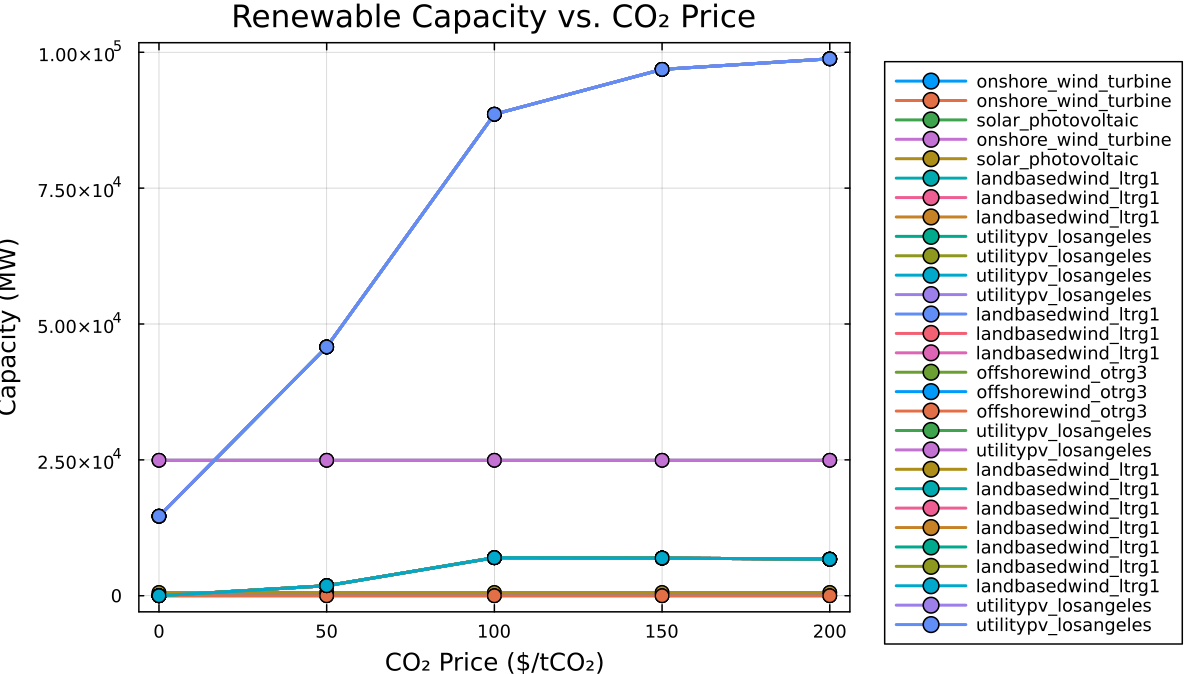

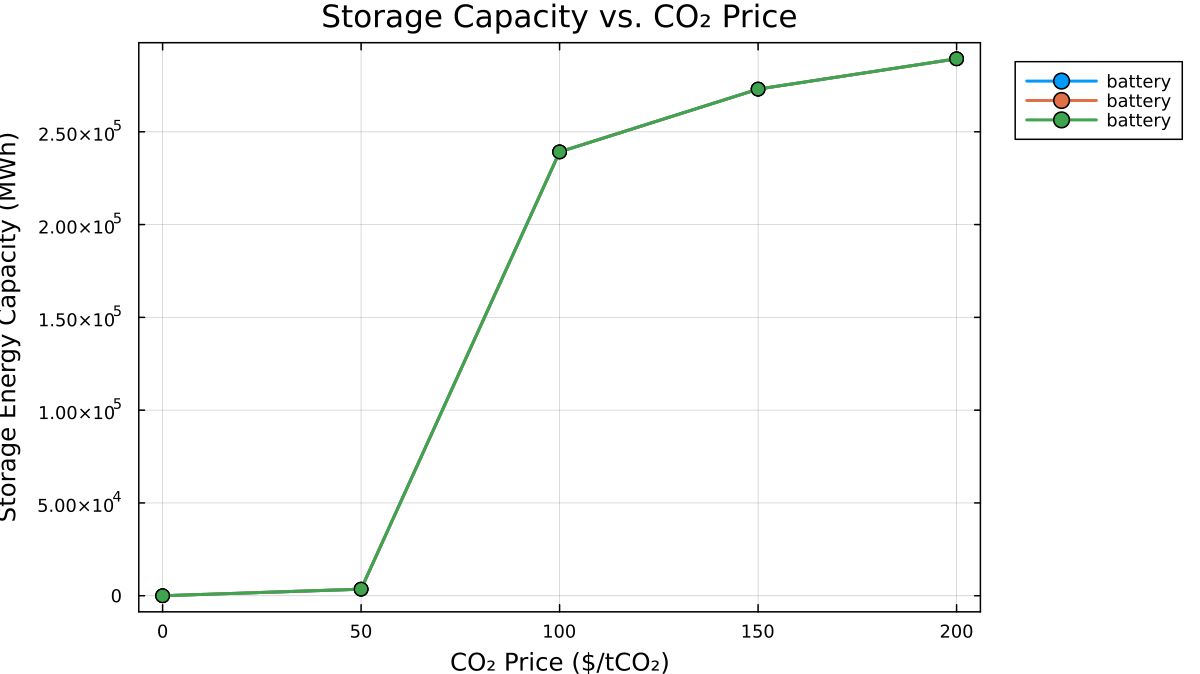

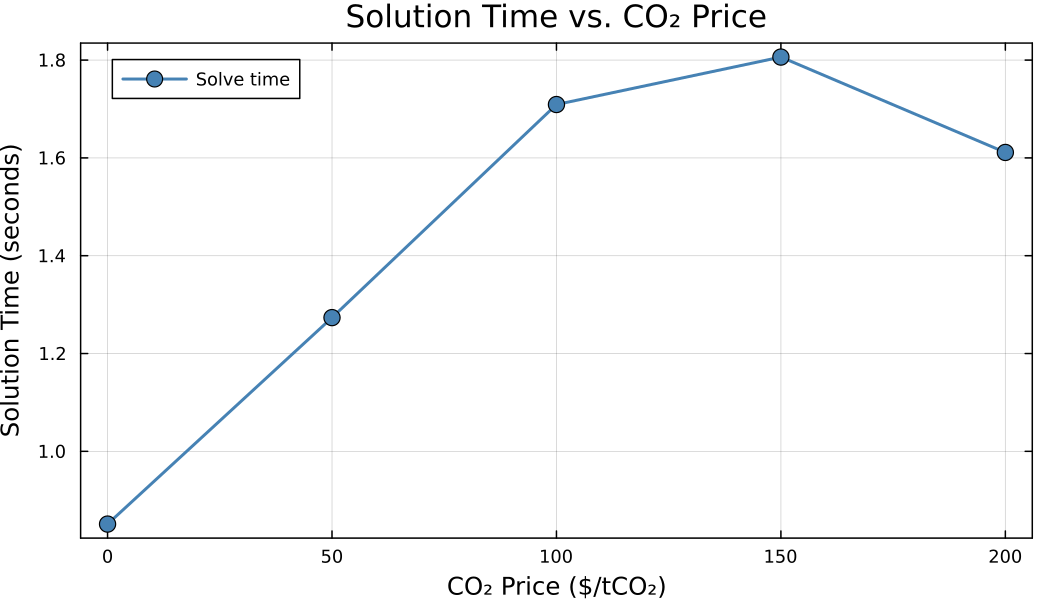

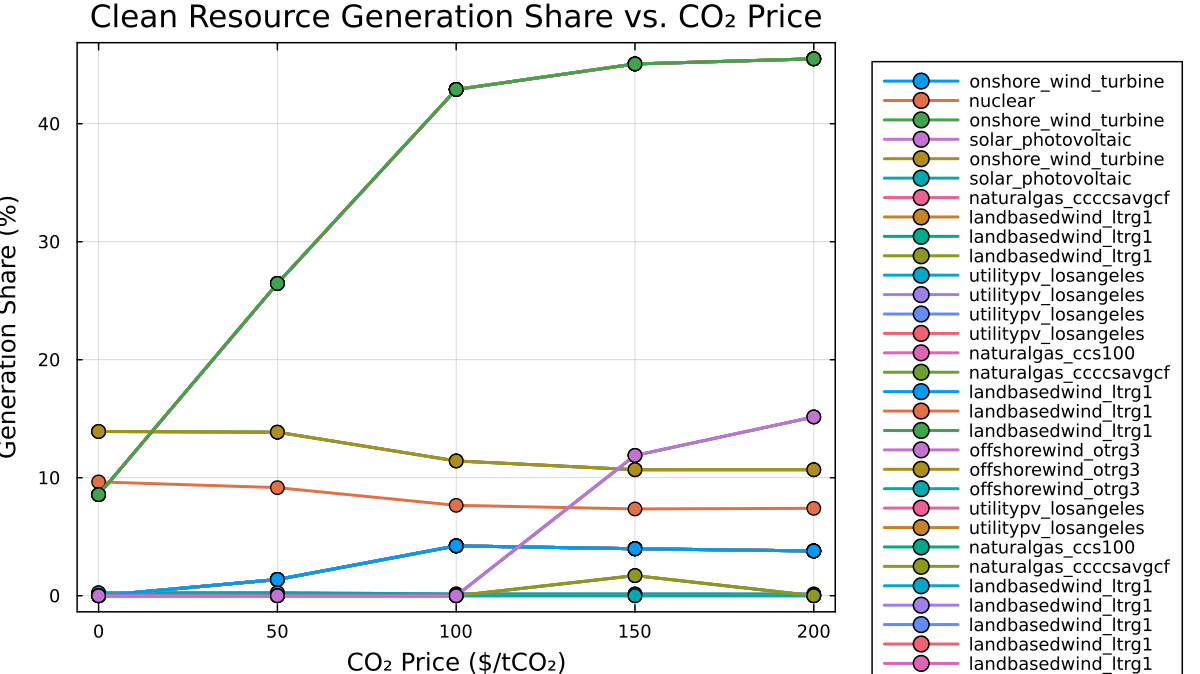

In [68]:
display(p_vre)
display(p_stor)
display(p_time)
display(p_ces)

As CO2 price rises we see storage capacity go way up to aid in reducing curtailment and better utilizing renewable energy resources like solar.